# Análisis de Farmanorte
Este notebook presenta un análisis exploratorio de los datos operativos de Farmanorte con el objetivo de obtener información útil para apoyar la toma de decisiones relacionadas con ventas, inventario y rentabilidad.

El análisis se realiza utilizando Python, Pandas, Matplotlib y Seaborn sobre datos reales de una droguería, siguiendo un flujo de trabajo similar al de un analista de datos.

## Objetivos

- Comprender la estructura y calidad de los datos.
- Limpiar y transformar la información para su análisis.
- Analizar el comportamiento de productos, laboratorios y ventas.
- Identificar indicadores clave (KPIs) y oportunidades de mejora.
- Generar visualizaciones que faciliten la interpretación de los resultados.

## Estructura

1. Configuración del entorno
2. Carga de los datos
3. Exploración y calidad de los datos
4. Limpieza y transformación
5. Análisis exploratorio (EDA)
6. Cálculo de indicadores (KPIs)
7. Visualizaciones
8. Hallazgos y recomendaciones
9. Exportación de resultados

In [1]:
# Configuración del entorno y librerías

import sqlite3
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de gráficos
plt.style.use("seaborn-v0_8")
sns.set_theme(style="whitegrid")

# Ruta del proyecto
PROJECT_ROOT = Path.cwd().resolve()

if not (PROJECT_ROOT / "database" / "farmanorte.db").exists():
    PROJECT_ROOT = Path("/home/cristhiam/data-analytics-portafolio/proyecto-farmanorte").resolve()

# Base de datos
DB_PATH = PROJECT_ROOT / "database" / "farmanorte.db"

# Carpeta de datos
RAW_DATA_DIR = PROJECT_ROOT / "data" / "raw"
PROCESSED_DATA_DIR = PROJECT_ROOT / "data" / "processed"

print(f"Proyecto: {PROJECT_ROOT}")
print(f"Base de datos encontrada: {DB_PATH.exists()}")
print(f"Carpeta de datos originales: {RAW_DATA_DIR.exists()}")
print(f"Carpeta de datos procesados: {PROCESSED_DATA_DIR.exists()}")

Proyecto: /home/cristhiam/data-analytics-portafolio/proyecto-farmanorte
Base de datos encontrada: True
Carpeta de datos originales: True
Carpeta de datos procesados: True


In [2]:
# Carga de datasets de ejemplo

import os
import sqlite3
from pathlib import Path

import pandas as pd

conn = sqlite3.connect(DB_PATH)

laboratorios = pd.read_sql_query('''
SELECT laboratorio,
       SUM(COALESCE(val_vendido, 0)) AS total_vendido,
       COUNT(*) AS productos
FROM matriz_bcg
GROUP BY laboratorio
ORDER BY total_vendido DESC
LIMIT 10
''', conn)

vendedores = pd.read_sql_query('''
SELECT v.nombre_vendedor,
       COUNT(*) AS cantidad_ventas,
       SUM(COALESCE(ve.valor_base, 0) * COALESCE(ve.cantidad, 0)) AS total_vendido,
       SUM(COALESCE(ve.valor_comision, 0)) AS total_comision
FROM ventas_especiales ve
JOIN vendedores v ON ve.id_vendedor = v.id_vendedor
GROUP BY v.nombre_vendedor
ORDER BY total_vendido DESC
LIMIT 10
''', conn)

productos = pd.read_sql_query('''
SELECT producto, laboratorio, COALESCE(existencia, 0) AS existencia, COALESCE(val_vendido, 0) AS val_vendido
FROM matriz_bcg
ORDER BY val_vendido DESC
LIMIT 12
''', conn)

conn.close()

# Guardar datasets de ejemplo para reproducibilidad
laboratorios.to_csv(PROCESSED_DATA_DIR / 'laboratorios_top.csv', index=False)
vendedores.to_csv(PROCESSED_DATA_DIR / 'vendedores_top.csv', index=False)
productos.to_csv(PROCESSED_DATA_DIR / 'productos_top.csv', index=False)

print('Dataset laboratorios:')
display(laboratorios.head())
print('Dataset vendedores:')
display(vendedores.head())
print('Dataset productos:')
display(productos.head())

Dataset laboratorios:


,laboratorio,total_vendido,productos
0,TRIDEX FARMACEUTICA,7825000.0,62
1,NESTLE NUTRICION,5079700.0,23
2,ABBOTT NUTRICION,4761270.0,24
3,A.G. MEDICAMENTOS,3289500.0,32
4,HALEON (GLAXO OTC),3012170.0,35


Dataset vendedores:


,nombre_vendedor,cantidad_ventas,total_vendido,total_comision
0,Cristhiam Adrian Botero Rojas,323,76301865.0,675199.0
1,Jorge Hernando Sanjuan Vega,202,59197795.0,436604.0
2,John Pablo Hernandez Arevalo,162,33179730.0,289411.0
3,Esteban Sandoval,56,12288777.0,110028.0
4,Jefferson Andres Castrillon Piã±Uela,57,9580355.0,81623.0


Dataset productos:


,producto,laboratorio,existencia,val_vendido
0,MOUNJARO 2.5MG/0.5ML * 1 AMP,ELI LILLY INTERAMERICA INC,4,2287760.0
1,ELECTROLIT MARACUYA * 625 ML,PISA (SUEROS LIQUIDOS),71,1615680.0
2,ENTEROGERMINA * 10 AMP,OPELLA (SANOFI OTC),6,991050.0
3,NESTOGENO TOTAL COMFORT *400 GR,NESTLE NUTRICION,3,868000.0
4,PEDIALYTE MAX ZINC 60 FRESA * 500 ML,ABBOTT NUTRICION,37,864050.0


In [3]:
# Exploración inicial del dataset

laboratorios.info()
print('\n')
laboratorios.describe(include='all')
print('\n')
print('Valores nulos:')
print(laboratorios.isna().sum())

vendedores.info()
print('\n')
vendedores.describe(include='all')
print('\n')
print('Valores nulos:')
print(vendedores.isna().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   laboratorio    10 non-null     object 
 1   total_vendido  10 non-null     float64
 2   productos      10 non-null     int64  
dtypes: float64(1), int64(1), object(1)
memory usage: 368.0+ bytes




Valores nulos:
laboratorio      0
total_vendido    0
productos        0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   nombre_vendedor  6 non-null      object 
 1   cantidad_ventas  6 non-null      int64  
 2   total_vendido    6 non-null      float64
 3   total_comision   6 non-null      float64
dtypes: float64(2), int64(1), object(1)
memory usage: 320.0+ bytes




Valores nulos:
nombre_vendedor    0
cantidad_ventas    0
total_vendido      

In [4]:
# Limpieza y transformación de datos

# Convertir columnas numéricas cuando sea necesario
for col in ['total_vendido', 'productos']:
    if col in laboratorios.columns:
        laboratorios[col] = pd.to_numeric(laboratorios[col], errors='coerce').fillna(0)

for col in ['cantidad_ventas', 'total_vendido', 'total_comision']:
    if col in vendedores.columns:
        vendedores[col] = pd.to_numeric(vendedores[col], errors='coerce').fillna(0)

for col in ['existencia', 'val_vendido']:
    if col in productos.columns:
        productos[col] = pd.to_numeric(productos[col], errors='coerce').fillna(0)

# Crear un resumen analítico combinado
summary = laboratorios.merge(vendedores, left_on='laboratorio', right_on='nombre_vendedor', how='outer')
summary = summary.fillna({'total_vendido_x': 0, 'productos': 0, 'cantidad_ventas': 0, 'total_vendido_y': 0, 'total_comision': 0})
summary.head()

,laboratorio,total_vendido_x,productos,nombre_vendedor,cantidad_ventas,total_vendido_y,total_comision
0,A.G. MEDICAMENTOS,3289500.0,32.0,NaN,0.0,0.0,0.0
1,ABBOTT NUTRICION,4761270.0,24.0,NaN,0.0,0.0,0.0
2,NaN,0.0,0.0,Cristhiam Adrian Botero Rojas,323.0,76301865.0,675199.0
3,ECAR,2422300.0,28.0,NaN,0.0,0.0,0.0
4,ELI LILLY INTERAMERICA INC,2929780.0,2.0,NaN,0.0,0.0,0.0


In [5]:
# Análisis de Farmanorte

# Top 10 laboratorios por valor vendido
lab_top = laboratorios.head(10).copy()
lab_top = lab_top.sort_values('total_vendido', ascending=False)

# Top 10 vendedores por desempeño
vendor_top = vendedores.head(10).copy()
vendor_top = vendor_top.sort_values('total_vendido', ascending=False)

# Top 10 productos por valor vendido
product_top = productos.head(10).copy()
product_top = product_top.sort_values('val_vendido', ascending=False)

print('Laboratorios más relevantes:')
display(lab_top)
print('Vendedores más relevantes:')
display(vendor_top)
print('Productos más relevantes:')
display(product_top)

Laboratorios más relevantes:


,laboratorio,total_vendido,productos
0,TRIDEX FARMACEUTICA,7825000.0,62
1,NESTLE NUTRICION,5079700.0,23
2,ABBOTT NUTRICION,4761270.0,24
3,A.G. MEDICAMENTOS,3289500.0,32
4,HALEON (GLAXO OTC),3012170.0,35
5,ELI LILLY INTERAMERICA INC,2929780.0,2
6,TECNOQUIMICAS WINNY,2821700.0,15
7,MK ETICOS CONVENIO,2734300.0,49
8,PISA (SUEROS LIQUIDOS),2594680.0,9
9,ECAR,2422300.0,28


Vendedores más relevantes:


,nombre_vendedor,cantidad_ventas,total_vendido,total_comision
0,Cristhiam Adrian Botero Rojas,323,76301865.0,675199.0
1,Jorge Hernando Sanjuan Vega,202,59197795.0,436604.0
2,John Pablo Hernandez Arevalo,162,33179730.0,289411.0
3,Esteban Sandoval,56,12288777.0,110028.0
4,Jefferson Andres Castrillon Piã±Uela,57,9580355.0,81623.0
5,Wilmer Armando Durã¡N Malagon,1,289200.0,2892.0


Productos más relevantes:


,producto,laboratorio,existencia,val_vendido
0,MOUNJARO 2.5MG/0.5ML * 1 AMP,ELI LILLY INTERAMERICA INC,4,2287760.0
1,ELECTROLIT MARACUYA * 625 ML,PISA (SUEROS LIQUIDOS),71,1615680.0
2,ENTEROGERMINA * 10 AMP,OPELLA (SANOFI OTC),6,991050.0
3,NESTOGENO TOTAL COMFORT *400 GR,NESTLE NUTRICION,3,868000.0
4,PEDIALYTE MAX ZINC 60 FRESA * 500 ML,ABBOTT NUTRICION,37,864050.0
5,POSTDAY * 2 TAB,ABBOTT FARMA CONVENIO,1,798000.0
6,KLIM 1+ BOLSA * 1000 GR,NESTLE NUTRICION,4,702600.0
7,EREX BEBIDA * 500 ML,LAB PHARMACIENCIA SAS,10,683500.0
8,GRIPAC * 10 CAP,TRIDEX FARMACEUTICA,0,651100.0
9,MOUNJARO 5MG/0.5ML * 1 AMP,ELI LILLY INTERAMERICA INC,0,642020.0


/tmp/ipykernel_6386/3465833355.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=lab_top, x='total_vendido', y='laboratorio', palette='viridis', ax=axes[0])
/tmp/ipykernel_6386/3465833355.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=vendor_top, x='total_vendido', y='nombre_vendedor', palette='magma', ax=axes[1])
/tmp/ipykernel_6386/3465833355.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=product_top, x='val_vendido', y='producto', palette='rocket', ax=axes[2])


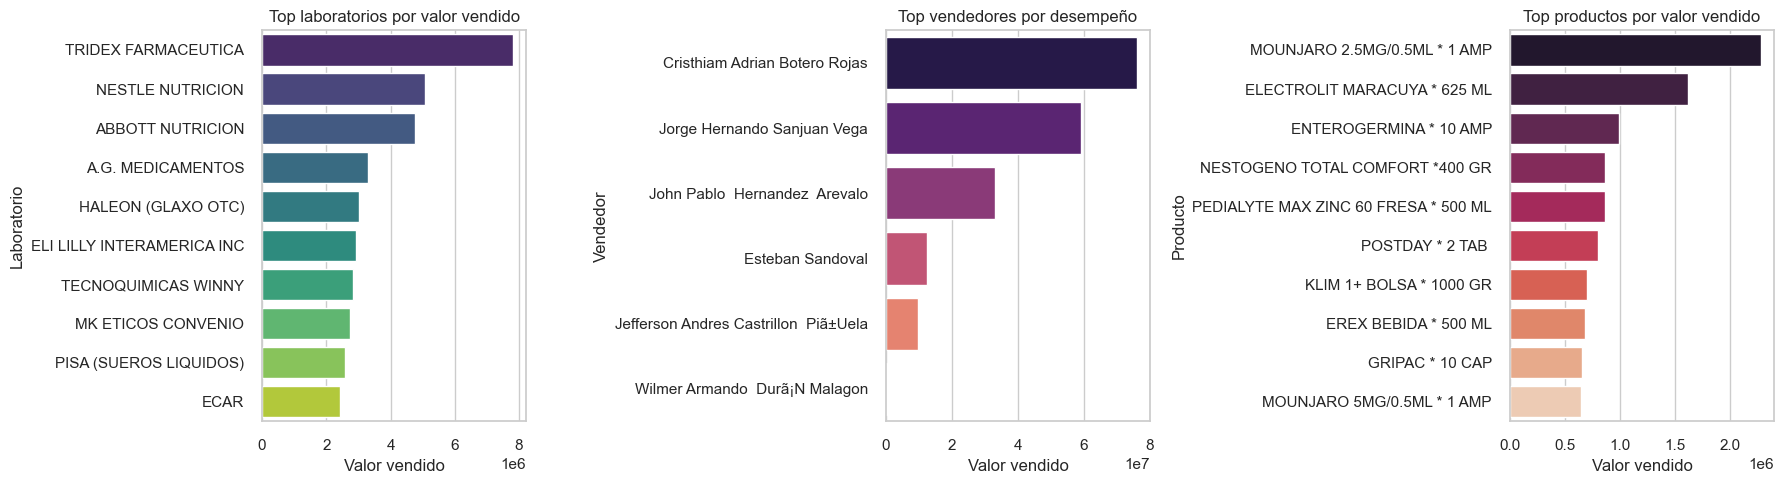

In [6]:
# Visualizaciones con Matplotlib y Seaborn

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.barplot(data=lab_top, x='total_vendido', y='laboratorio', palette='viridis', ax=axes[0])
axes[0].set_title('Top laboratorios por valor vendido')
axes[0].set_xlabel('Valor vendido')
axes[0].set_ylabel('Laboratorio')

sns.barplot(data=vendor_top, x='total_vendido', y='nombre_vendedor', palette='magma', ax=axes[1])
axes[1].set_title('Top vendedores por desempeño')
axes[1].set_xlabel('Valor vendido')
axes[1].set_ylabel('Vendedor')

sns.barplot(data=product_top, x='val_vendido', y='producto', palette='rocket', ax=axes[2])
axes[2].set_title('Top productos por valor vendido')
axes[2].set_xlabel('Valor vendido')
axes[2].set_ylabel('Producto')

plt.tight_layout()
plt.show()

In [7]:
# Comparaciones y métricas clave

# Crear una métrica de relación valor/stock para productos
productos['ratio_valor_stock'] = np.where(productos['existencia'] > 0, productos['val_vendido'] / productos['existencia'], np.nan)
productos[['producto', 'existencia', 'val_vendido', 'ratio_valor_stock']].sort_values('ratio_valor_stock', ascending=False).head(10)

# Resumen ejecutivo simple
print('Total de laboratorios analizados:', laboratorios['laboratorio'].nunique())
print('Mejor vendedor:', vendedores.loc[vendedores['total_vendido'].idxmax(), 'nombre_vendedor'])
print('Producto con mayor valor vendido:', productos.loc[productos['val_vendido'].idxmax(), 'producto'])

Total de laboratorios analizados: 10
Mejor vendedor: Cristhiam Adrian Botero Rojas
Producto con mayor valor vendido: MOUNJARO 2.5MG/0.5ML * 1 AMP


In [8]:
# Exportación de resultados y recursos

# Guardar resultados derivados
OUTPUT_DIR = PROJECT_ROOT / 'data' / 'portfolio_outputs'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

lab_top.to_csv(OUTPUT_DIR / 'lab_top.csv', index=False)
vendor_top.to_csv(OUTPUT_DIR / 'vendor_top.csv', index=False)
product_top.to_csv(OUTPUT_DIR / 'product_top.csv', index=False)

print('Archivos exportados en:', OUTPUT_DIR)
print('Listo para compartir como portafolio.')

Archivos exportados en: /home/cristhiam/data-analytics-portafolio/proyecto-farmanorte/data/portfolio_outputs
Listo para compartir como portafolio.
